In [21]:
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from pathlib import Path

In [22]:
cwd = os.getcwd()

In [23]:
def read_vcf(filepath_or_buffer, usecols=None):
    with open(filepath_or_buffer) as vcf:
        while True:
            line = vcf.readline()
            if not line.startswith("##"):
                names = line[1:].split()
                break
        return pd.read_table(
             vcf, 
             sep="\t", 
             usecols=usecols, 
             header=None, 
             names=names
        )

In [43]:
folder = Path(cwd + "/../data/bcftools")

# QC all samples

Looking at 
- bulk RNA-seq data before any filtering is applied
- bulk RNA-seq data with a quality filter, QUAL>20, applied
- dissociated bulk RNA-seq data before any filtering is applied
- dissociated bulk RNA-seq data with a quality filter, QUAL>20, applied

At the level of individual samples

In [68]:
def load_data():
    output_dict = {}
    full_df = pd.DataFrame()
    file_patterns = [
        "sample_level/bcftools_bulk_sample*.vcf",
        "sample_level_filtered/bcftools_filtered_bulk_sample*.vcf",
        "sample_level/bcftools_diss_bulk_sample*.vcf",
        "sample_level_filtered/bcftools_filtered_diss_bulk_sample*.vcf",
    ]

    for p in file_patterns:
        diss_bulk_pattern = re.search(r"diss", p)
        filter_pattern = re.search(r"filtered", p)
        col_name = "diss_bulk" if diss_bulk_pattern else "bulk"
        if filter_pattern:
            col_name += "_filtered"
        print(col_name)

        for f in folder.glob(p):
            sample_id_pattern = re.search(r"\d{4}", f.name)
            df = read_vcf(f)
            output_dict[str(sample_id_pattern.group(0))] = len(df)

        df = pd.DataFrame(
            {
                "sample id": output_dict.keys(),
                col_name + "_length": output_dict.values()
            }
        )
        df["sample id"] = df["sample id"].astype(int)

        full_df = pd.merge(full_df, df, on="sample id", how="outer") if not full_df.empty else df

    full_df["bulk pct retained"] = (
        full_df["bulk_filtered_length"] / full_df["bulk_length"]
    )
    full_df["diss bulk pct retained"] = (
        full_df["diss_bulk_filtered_length"] / full_df["diss_bulk_length"]
    )

    return full_df


In [69]:
total_df = load_data()

bulk
bulk_filtered
diss_bulk
diss_bulk_filtered


In [70]:
total_df.head()

,sample id,bulk_length,bulk_filtered_length,diss_bulk_length,diss_bulk_filtered_length,bulk pct retained,diss bulk pct retained
0,2018,1326520,1181790,532494,447710,0.890895,0.840779
1,2023,1282252,1149840,432573,362526,0.896735,0.838069
2,2094,1251102,1128348,450298,389560,0.901883,0.865116
3,2126,1274778,1142817,568204,477696,0.896483,0.840712
4,2129,956921,843363,586049,479605,0.881330,0.818370


/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_16298/286098200.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20', 20)


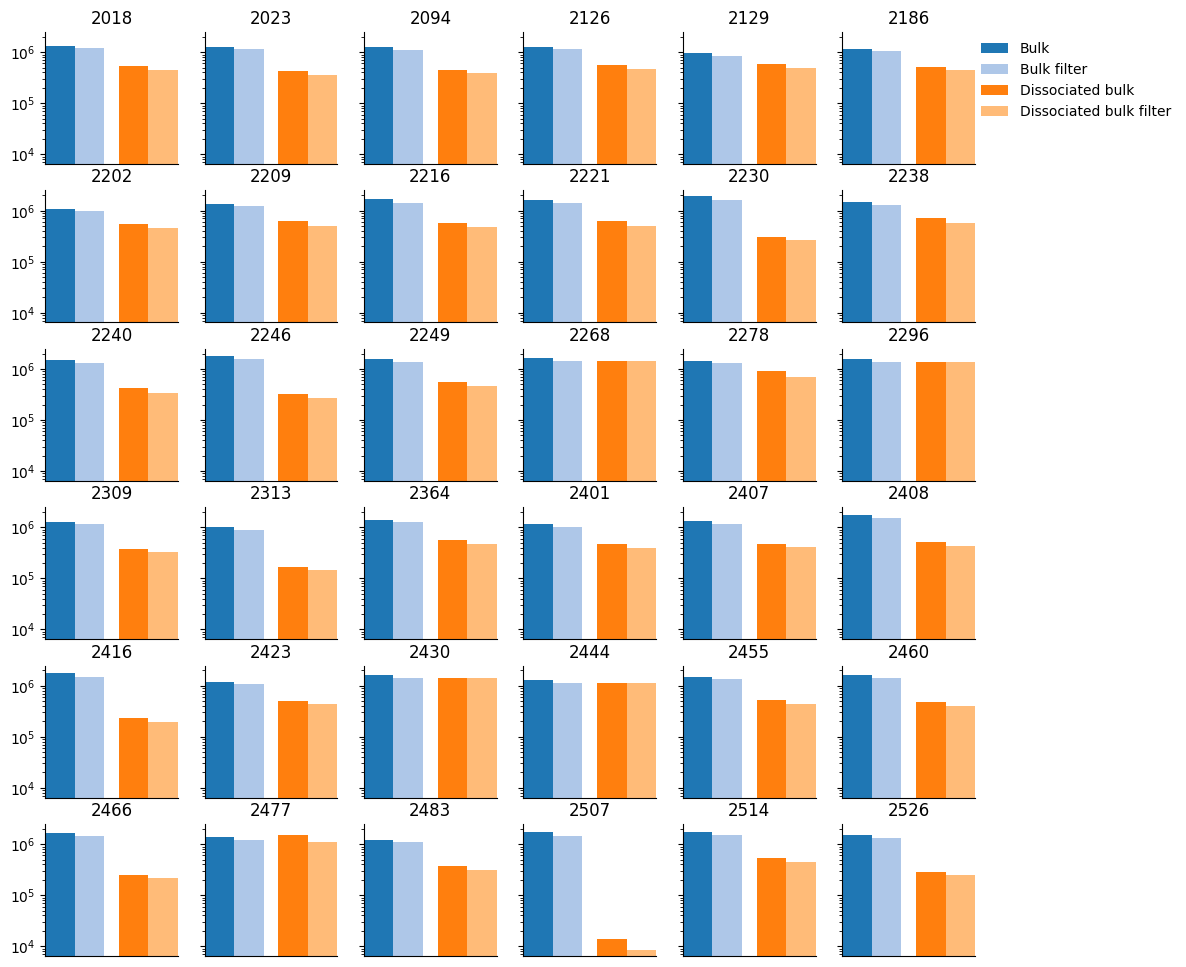

In [72]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharey=True)
tab20 = plt.cm.get_cmap('tab20', 20)
width = 0.25
offset = 0.5
for i in range(0, 6):
    for j in range(0, 6):
        k = (i * 6) + j
        # print((i, j), k)
        ax[i, j].bar([0], total_df["bulk_length"].iloc[k], width, label="Bulk", color=tab20(0))
        ax[i, j].bar([0.25], total_df["bulk_filtered_length"].iloc[k], width, label="Bulk filter", color=tab20(1/20))
        ax[i, j].bar([0.625], total_df["diss_bulk_length"].iloc[k], width, label="Dissociated bulk", color=tab20(2/20))
        ax[i, j].bar([0.875], total_df["diss_bulk_filtered_length"].iloc[k], width, label="Dissociated bulk filter", color=tab20(3/20))
        
        ax[i, j].spines['top'].set_visible(False)
        ax[i, j].spines['right'].set_visible(False)
        ax[i, j].set_title(total_df["sample id"].iloc[k])
        ax[i, j].set_xlim(-0.125, 1)
        ax[i, j].set_xticks([])
        ax[i, j].set_yscale("log")

ax[0, -1].legend(frameon=False, loc=(1, 0.3))

plt.show()

In [41]:
figname = "../figures/diss_vs_bulk_ref/number_of_variants_per_sample_barchart_log"
fig.savefig(figname + ".pdf", bbox_inches="tight")
fig.savefig(figname + ".png", bbox_inches="tight", dpi=300)